# Решающие деревья и случайный лес: реализация с нуля и сравнительный анализ

## Введение

В этом проекте мы напишем ручную NumPy реализацию решающего дерева, а затем сравним эту реализацию с `DecisionTreeClassifier`, `BaggingClassifier` и `RandomForestClassifier`.

**Структура ноутбука:**
1. Реализация `find_best_split` – поиск оптимального разбиения по критерию Джини / снижению дисперсии.
2. Тестирование на датасете California Housing.
3. Тестирование на датасете User Knowledge (students).
3. Реализация класса `DecisionTree`.
5. Бэггинг и случайный лес на датасете Diabetes.
6. Сравнительный анализ моделей.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import urllib.request
import io
from collections import Counter
from typing import Dict, List, Optional, Tuple, Union

## 1. Реализация `find_best_split`

Ключевой примитив для построения дерева – функция поиска наилучшего разбиения выборки по одному признаку. Для каждого возможного порога она вычисляет прирост информативности:

$$Q(R, j, t) = H(R) - \frac{|R_\ell|}{|R|}\,H(R_\ell) - \frac{|R_r|}{|R|}\,H(R_r)$$

где $H(R)$ – мера хаотичности узла:
- **Классификация:** критерий Джини $H(R) = 1 - \sum_k p_k^2$
- **Регрессия:** дисперсия $H(R) = \mathbb{D}[y]$

Реализация без явного цикла по порогам (векторизация через `np.cumsum`).

In [2]:
def find_best_split(
        feature_vector: Union[np.ndarray, pd.DataFrame],
        target_vector: Union[np.ndarray, pd.Series],
        task: str = "classification",
        feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов, len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    x = np.asarray(feature_vector).ravel()
    y = np.asarray(target_vector).ravel()

    # Критерий Джини (для классификации)
    def gini_from_counts(counts) -> np.ndarray:
        sizes = counts.sum(axis=1)
        probs = counts / sizes[:, None]
        return 1.0 - np.sum(probs ** 2, axis=1)

    # Дисперсия (для регрессии)
    def variance_from_sums(sum_y, sum_y2, n) -> np.ndarray:
        mean = sum_y / n
        return sum_y2 / n - mean ** 2

    if feature_type == "real":
        order = np.argsort(x)
        x_sorted = x[order]
        y_sorted = y[order]

        # Убираем признаки, по которым бессмысленно сделать сплит. Если таковые все, то выдаём NaN.
        valid = x_sorted[:-1] != x_sorted[1:]
        if valid.sum() == 0:
            return np.array([]), np.array([]), np.nan, np.nan

        thresholds_all = (x_sorted[:-1] + x_sorted[1:]) / 2
        thresholds = thresholds_all[valid]

        # Свяжем маску допустимых сплитов с реальными позициями разбиения.
        split_pos = np.flatnonzero(valid) + 1
        n = len(y_sorted)
        left_n = split_pos
        right_n = n - left_n

        if task == "classification":
            # Сделаем Ohe-Hot кодирование для признаков
            classes, y_enc = np.unique(y_sorted, return_inverse=True)
            k = len(classes)

            Y = np.eye(k)[y_enc]
            prefix = np.cumsum(Y, axis=0)
            total = prefix[-1]
            left_counts = prefix[split_pos - 1]
            right_counts = total - left_counts

            parent = 1.0 - np.sum((total / n) ** 2)
            weighted = (
                    left_n / n * gini_from_counts(left_counts)
                    + right_n / n * gini_from_counts(right_counts)
            )
            ginis = parent - weighted

        elif task == "regression":
            y_float = y_sorted
            prefix_sum = np.cumsum(y_float)
            prefix_sq = np.cumsum(y_float ** 2)

            total_sum = prefix_sum[-1]
            total_sq = prefix_sq[-1]

            left_sum = prefix_sum[split_pos - 1]
            left_sq = prefix_sq[split_pos - 1]
            right_sum = total_sum - left_sum
            right_sq = total_sq - left_sq

            parent = variance_from_sums(total_sum, total_sq, n)
            weighted = (
                    left_n / n * variance_from_sums(left_sum, left_sq, left_n)
                    + right_n / n * variance_from_sums(right_sum, right_sq, right_n)
            )
            ginis = parent - weighted

        best_idx = np.argmax(ginis)
        threshold_best = thresholds[best_idx]
        gini_best = ginis[best_idx]

        return thresholds, ginis, threshold_best, gini_best

    elif feature_type == "categorical":
        categories, x_enc = np.unique(x, return_inverse=True)
        m = len(categories)
        ginis = np.full(m, 0, dtype=float)

        if m <= 1:
            return np.array([]), np.array([]), np.nan, np.nan

        X = np.eye(m)[x_enc]
        left_n = X.sum(axis=0)
        right_n = len(y) - left_n
        valid = (left_n > 0) & (right_n > 0)

        if task == "classification":
            # Сделаем Ohe-Hot кодирование для классов

            classes, y_enc = np.unique(y, return_inverse=True)
            k = len(classes)
            Y = np.eye(k)[y_enc]  # Закодировали

            # Теперь вот такой финт:

            # X[obj, j] = 1: объект obj обладает категорией j
            # X.T[i, obj] = 1: категории i соответствует объект obj 
            # Y[obj, j] = 1: объект obj обладает классом j

            # Элемент left_counts[i, j]: это объект, который обладает категорией i и классом j, поскольку 
            # умножение производится следующим образом: берём в X.T строку, которая соответствует категории i, поэлементно умножаем её на столбец, в котором каждый из объектов обладает классом j. Получается сумма единичек, которые соответствуют тем obj, что обладает категорией i и классом j.
            # Более аккуратно left_counts[i, j] = (X.T @ Y)[category, cls] = sum_over_obj { X[obj, category] * Y[obj, cls] }

            # В результате получаем матрицу, отображающую сколько объектов той или иной категории обладают тем или иным классом

            left_counts = X.T @ Y
            total_counts = Y.sum(axis=0)
            right_counts = total_counts - left_counts

            parent = 1.0 - np.sum((total_counts.ravel() / len(y)) ** 2)

            ginis[valid] = (
                    parent
                    - (left_n[valid] / len(y)) * gini_from_counts(left_counts[valid])
                    - (right_n[valid] / len(y)) * gini_from_counts(right_counts[valid])
            )

        elif task == "regression":
            y_float = y.astype(float)
            y_sq = y_float ** 2

            left_sum = X.T @ y_float
            left_sq = X.T @ y_sq
            total_sum = y_float.sum()
            total_sq = y_sq.sum()

            right_sum = total_sum - left_sum
            right_sq = total_sq - left_sq

            parent = variance_from_sums(total_sum, total_sq, len(y))

            ginis[valid] = (
                    parent
                    - (left_n[valid] / len(y)) * variance_from_sums(left_sum[valid], left_sq[valid], left_n[valid])
                    - (right_n[valid] / len(y)) * variance_from_sums(right_sum[valid], right_sq[valid], right_n[valid])
            )

        # Убираем признаки, по которым бессмысленно сделать сплит. Если таковые все, то выдаём NaN.
        valid_idx = np.isfinite(ginis)
        if valid_idx.sum() == 0:
            return np.array([]), np.array([]), np.nan, np.nan

        thresholds = categories[valid_idx]
        ginis = ginis[valid_idx]

        best_idx = np.argmax(ginis)
        threshold_best = thresholds[best_idx]
        gini_best = ginis[best_idx]

        return thresholds, ginis, threshold_best, gini_best

    pass

## 2. Анализ датасета California Housing

Перед построением дерева изучим датасет встроенный в sklearn датасет `fetch_california_housing`. Датасет содержит информацию о жилых блоках в Калифорнии: медианный доход, возраст домов, количество комнат и т.д. Целевая переменная – медианная стоимость дома в сотнях тысяч долларов.


In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### 2.1 Поиск лучшего предиката корня дерева

Переберём все признаки и найдём тот, по которому первое разбиение даёт наибольший прирост критерия.

In [5]:
best_gain = 0.0
best_feature = None
best_threshold = None

for col in X.columns:
    thresholds, ginis, threshold_best, gini_best = find_best_split(
        X[col], y, task="regression", feature_type="real"
    )
    if not np.isnan(gini_best) and gini_best > best_gain:
        best_gain = gini_best
        best_feature = col
        best_threshold = threshold_best

print(f"best_feature   : {best_feature}")
print(f"best_threshold : {best_threshold:.5f}")
print(f"best_gain      : {best_gain:.6f}")

best_feature   : MedInc
best_threshold : 5.03515
best_gain      : 0.412751


Признак `MedInc` (медианный доход) является лучшим предикатом для первого разбиения.  Так вышло, потому что от остальных признаков стоимость в основном растёт линейно (например, редко когда от размеров дома зависимость какая-то очень хитрая, в первую очередь стоимость строится из количества квадратных метров), и для модели не совсем понятно, как наиболее выгодно сделать разделение.

### 2.2 Визуализация критерия информативности

Построим кривую зависимости прироста информативности от порога для признака `MedInc`.  

In [6]:
thresholds, ginis, threshold_best, gini_best = find_best_split(X.iloc[:, 0], y, task="regression", feature_type="real")
print(f"thresholds: {thresholds}")
print(f"ginis: {ginis}")
print(f"threshold_best: {threshold_best}")
print(f"gini_best: {gini_best}")

thresholds: [ 0.51795  0.54275  0.5964  ... 14.7421  14.95045 15.00005]
ginis: [0.0001088  0.0001856  0.0002249  ... 0.0199786  0.01956096 0.01872587]
threshold_best: 5.03515
gini_best: 0.41275138620195606


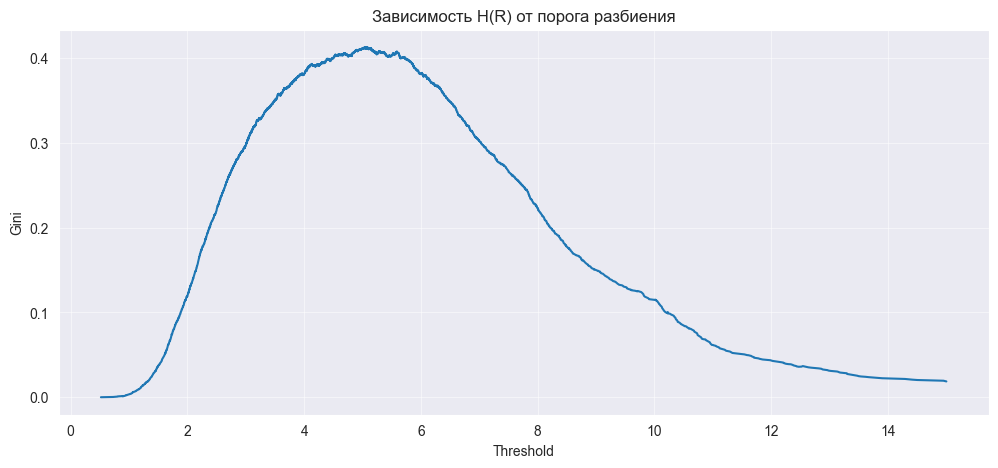

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(thresholds, ginis)
plt.xlabel("Threshold")
plt.ylabel("Gini")
plt.title("Зависимость H(R) от порога разбиения")
plt.grid(True, alpha=0.5)
plt.show()

График показывает характерный пик – область порога, в которой дерево получает максимальный выигрыш от разбиения.

## 3. Тестирование на датасете User Knowledge (students)

Датасет `students.csv` – адаптированная версия [User Knowledge Modeling Dataset](https://archive.ics.uci.edu/dataset/257/user+knowledge+modeling). Он содержит 5 вещественных признаков, описывающих поведение студента при работе с учебными материалами, и бинарную целевую переменную (уровень знаний: 0 или 1).

Посмотрим, насколько хорошо каждый признак разделяет классы, опираясь на кривые прироста критерия Джини и KDE-распределения.

In [8]:
import urllib.request, io

_url = "https://raw.githubusercontent.com/untitled-knight/trees-rf-project/refs/heads/main/students.csv"
with urllib.request.urlopen(_url) as _r:
    students_raw = _r.read().decode()

data_stu = pd.read_csv(io.StringIO(students_raw))
# Ненужный столбец-нумерация
data_stu.drop(columns=[c for c in data_stu.columns if "Unnamed" in c], inplace=True)

X_stu = data_stu.iloc[:, :-1]
y_stu = data_stu.iloc[:, -1]
columns = X_stu.columns

X_stu.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


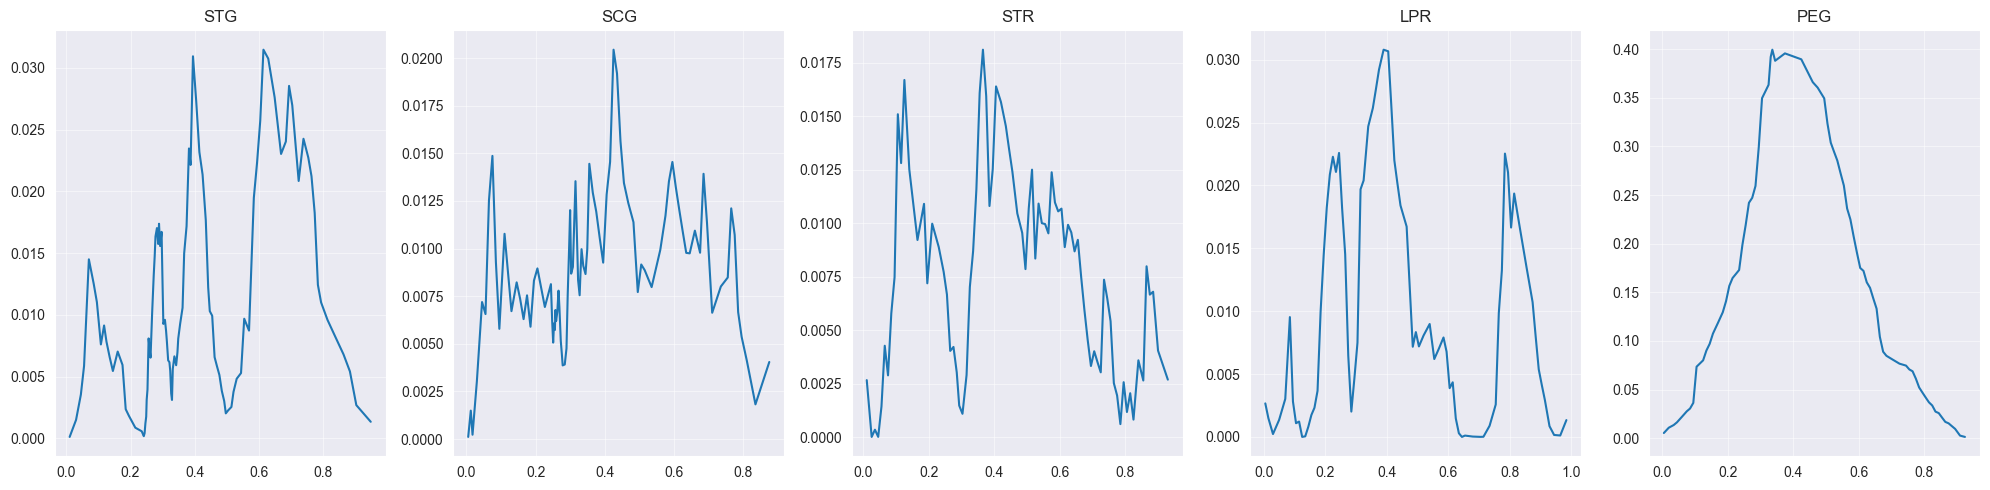

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for index, column in enumerate(columns):
    thresholds, ginis, threshold_best, gini_best = find_best_split(X_stu[column], y_stu, task="classification",
                                                                   feature_type="real")
    axes[index].plot(thresholds, ginis)
    axes[index].set_title(column)
    axes[index].grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

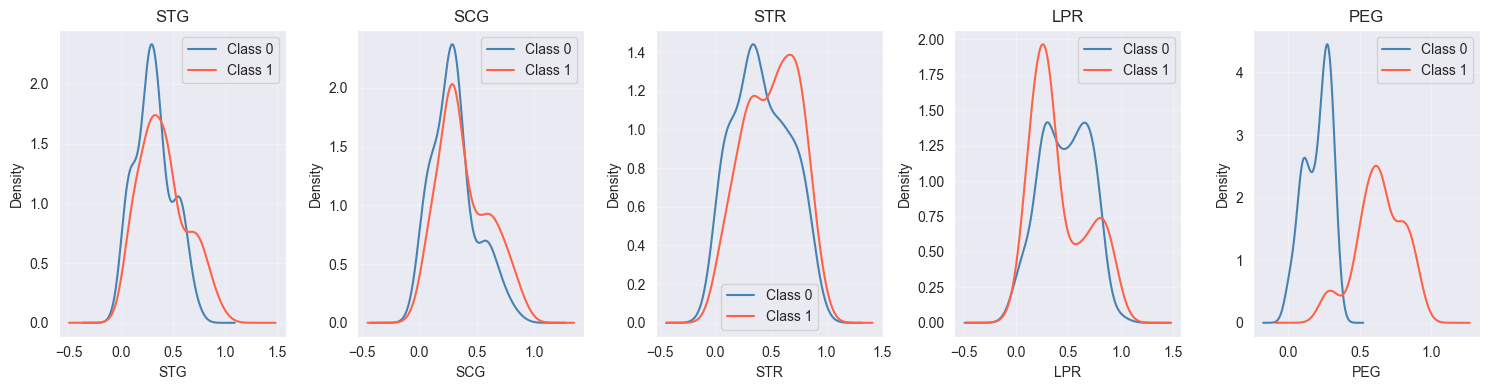

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for index, column in enumerate(columns):
    X_stu[column][y_stu == 0].plot.kde(ax=axes[index], label="Class 0", color="steelblue")
    X_stu[column][y_stu == 1].plot.kde(ax=axes[index], label="Class 1", color="tomato")

    axes[index].set_title(column)
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Density")
    axes[index].legend()
    axes[index].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод.** Будем производить деление на два поддерева по признаку PEG, поскольку для него значения критерия информативности выше. 
Результаты согласуются, поскольку по диаграмме рассеивания для PEG видно, что кривые не пересекаются, т.е. модель хорошо различает классы. Чего не скажешь об остальных признаках: по ним модель плохо различает классы, видно что кривые чуть-ли не совпадают, поэтому по ним делить не будем.

## 4. Реализация класса `DecisionTree`

Строим дерево жадно: начиная с корня, в каждом узле выбираем признак и порог с максимальным приростом критерия. Рекурсия останавливается, когда все объекты в листе принадлежат одному классу, либо ни по одному признаку нельзя произвести разбиение с положительным приростом.

Реализованы методы:
- `_fit_node` – рекурсивное построение узла
- `_predict_node` – рекурсивное предсказание для одного объекта
- `fit` / `predict` – публичный API

In [11]:
class DecisionTree:
    """
    Дерево строится жадным алгоритмом: на каждом шаге выбирается
    признак и порог, дающие максимальный прирост информативности.
    Для классификации используется критерий Джини, для регрессии –
    снижение дисперсии.

    Параметры:
    :param feature_types: list of str
        Типы признаков: "real" или "categorical".
    :param max_depth: int, optional
        Максимальная глубина дерева. 'None' – без ограничений.
    :param min_samples_split: int, optional
        Минимальное число объектов для разбиения узла.
    :param min_samples_leaf: int, optional
        Минимальное число объектов в листе.
    :param task: str
        "classification" или "regression".
    """

    def __init__(
            self,
            feature_types: Union[List[str], np.ndarray],
            max_depth: Optional[int] = None,
            min_samples_split: Optional[int] = None,
            min_samples_leaf: Optional[int] = None,
            task: str = "classification",
    ) -> None:
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree: dict = {}
        self._feature_types: Union[List[str], np.ndarray] = feature_types
        self._max_depth: Optional[int] = max_depth
        self._min_samples_split: Optional[int] = min_samples_split
        self._min_samples_leaf: Optional[int] = min_samples_leaf
        self.task: str = task
        self._feature_importances: Dict[int, float] = {}

    def _fit_node(
            self,
            sub_X: np.ndarray,
            sub_y: np.ndarray,
            node: dict,
    ) -> None:
        """
        Рекурсивно строит узел дерева.

        Параметры:
        :param sub_X: np.ndarray, shape (n_samples, n_features)
            Матрица признаков для текущей подвыборки.
        :param sub_y: np.ndarray, shape (n_samples,)
            Вектор целевых значений для текущей подвыборки.
        :param node: dict
            Словарь, в который записываются параметры узла.

        :return None  (результат записывается в "node" на месте)
        """
        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best: Optional[int] = None
        threshold_best: Optional[float] = None
        gini_best: Optional[float] = None
        split: Optional[np.ndarray] = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            # nan означает, что по этому признаку разбиение невозможно – пропускаем
            if np.isnan(gini):
                continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector <= threshold_best
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector == threshold_best
                else:
                    raise ValueError(f"Unknown feature type: {feature_type}")

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None or split is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best

        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[~split], sub_y[~split], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> Union[int, float]:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """

        if node["type"] == "terminal":
            return node["class"]

        feature: int = node["feature_split"]
        feature_type: str = self._feature_types[feature]

        if feature_type == "real":
            go_left = x[feature] <= node["threshold"]
        elif feature_type == "categorical":
            go_left = x[feature] == node["category_split"]
        else:
            raise ValueError(f"Unknown feature type: {feature_type}")

        return self._predict_node(x, node["left_child"] if go_left else node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Обучает дерево на обучающей выборке.
        
        Параметры:
        :param X: np.ndarray, shape (n_samples, n_features)
        :param y: np.ndarray, shape (n_samples,)
        :return None
        """
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Предсказывает целевую переменную для набора объектов.

        Параметры:
        :param X: np.ndarray, shape (n_samples, n_features)
        :return np.ndarray, shape (n_samples,)
        """
        return np.array([self._predict_node(x, self._tree) for x in X])

## 5. Бэггинг и случайный лес на Diabetes

Теперь перейдём к ансамблевым методам. Используем датасет [Diabetes](https://github.com/untitled-knight/trees-rf-project/blob/main/diabetes.csv): 768 пациентов, 8 медицинских признаков, таргет – наличие диабета.

### 5.1 Загрузка и первичный анализ данных

In [12]:
import urllib.request, io
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

_url = "https://raw.githubusercontent.com/untitled-knight/trees-rf-project/refs/heads/main/diabetes.csv"
with urllib.request.urlopen(_url) as _r:
    diabetes_raw = _r.read().decode()

data = pd.read_csv(io.StringIO(diabetes_raw))
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной, чтобы оценить дисбаланс классов. Это важно для выбора метрики: при значительном дисбалансе accuracy может быть неинформативной – поэтому мы используем также precision, recall и AUC-ROC.

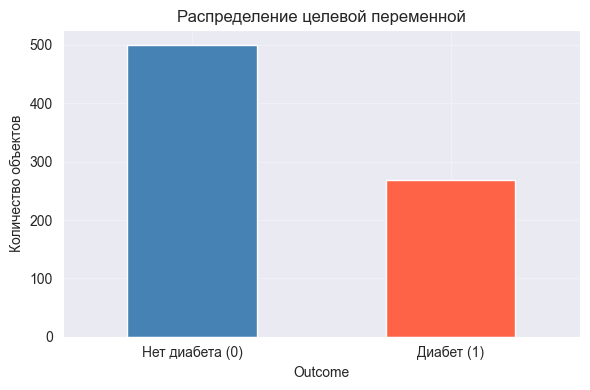

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
data["Outcome"].value_counts().plot.bar(ax=ax, color=["steelblue", "tomato"])
ax.set_xticklabels(["Нет диабета (0)", "Диабет (1)"], rotation=0)
ax.set_ylabel("Количество объектов")
ax.set_title("Распределение целевой переменной")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Классы несбалансированы примерно в отношении 65:35 (нет диабета : диабет). Это умеренный дисбаланс – используем стратификацию при разбивке данных и оцениваем модель по нескольким метрикам.

### 5.2 Разбивка на обучающую, валидационную и тестовую выборки

Разбиваем данные в соотношении 70% train / 30% test, а обучающую часть дополнительно делим 70/30 на train-train и validation. Итого:
- train-train: ~49% датасета
- validation: ~21%
- test: 30%


In [14]:
y = data['Outcome']
x = data.drop('Outcome', axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
x_double_train, x_val, y_double_train, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42,
                                                                stratify=y_train)

### 5.3 Одиночное решающее дерево с подбором гиперпараметров

Подбираем `max_depth` и `min_samples_leaf` по сетке на валидационной выборке, используя F1-score как основной критерий.

In [15]:
from sklearn.metrics import f1_score

max_depth_values = np.arange(1, 30)
min_samples_leaf_values = np.arange(1, 30)

hyperparameters = []

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
        model.fit(x_double_train, y_double_train)
        y_pred = model.predict(x_val)

        score = f1_score(y_val, y_pred)

        hyperparameters.append([max_depth, min_samples_leaf, score])

best_hyperparameters = max(hyperparameters, key=lambda x: x[2])[:-1]

best_model = DecisionTreeClassifier(max_depth=best_hyperparameters[0], min_samples_leaf=best_hyperparameters[1],
                                    random_state=42)
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

print(f"max_depth_best: {best_hyperparameters[0]}")
print(f"min_samples_leaf_best: {best_hyperparameters[1]}")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"AUC: {roc_auc_score(y_test, y_proba)}")

max_depth_best: 5
min_samples_leaf_best: 17
Accuracy: 0.7532467532467533
Precision: 0.7307692307692307
Recall: 0.4691358024691358
AUC: 0.8047325102880658


### 5.4 Бэггинг (Bootstrap Aggregating)

Обучим `BaggingClassifier` на 50 деревьях на полной обучающей выборке и оценим качество классификации по тем же матрикам.

In [16]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bagging.fit(x_train, y_train)

y_pred = bagging.predict(x_test)
y_proba = bagging.predict_proba(x_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"AUC: {roc_auc_score(y_test, y_proba)}")

Accuracy: 0.7532467532467533
Precision: 0.6875
Recall: 0.5432098765432098
AUC: 0.8269135802469136


### 5.5 Случайный лес с подбором гиперпараметров

Случайный лес дополнительно вводит случайный выбор признаков для каждого разбиения (параметр `max_features`). Это помогает снизить общую дисперсию ансамбля сильнее, чем простой бэггинг.

Подбираем `max_depth` и `min_samples_split` через 10-fold Stratified CV на полной обучающей выборке.

In [17]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

max_depth_values = np.arange(1, 20)
min_samples_split_values = np.arange(2, 15)

hyperparameters = []

for max_depth in max_depth_values:
    for min_samples_split in min_samples_split_values:
        model = RandomForestClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1,
            n_estimators=50
        )

        cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
        scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='f1')
        score = scores.mean()

        hyperparameters.append([max_depth, min_samples_split, score])

best_hyperparameters = max(hyperparameters, key=lambda x: x[2])[:-1]

best_model = RandomForestClassifier(
    max_depth=best_hyperparameters[0],
    min_samples_split=best_hyperparameters[1],
    random_state=42,
    n_jobs=-1,
    n_estimators=50
)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

print(f"max_depth_best: {best_hyperparameters[0]}")
print(f"min_samples_split_best: {best_hyperparameters[1]}")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"AUC: {roc_auc_score(y_test, y_proba)}")

max_depth_best: 17
min_samples_split_best: 7
Accuracy: 0.7445887445887446
Precision: 0.6666666666666666
Recall: 0.5432098765432098
AUC: 0.8206584362139917


### 5.6 Зависимость AUC-ROC от числа деревьев

Исследуем, как растёт качество случайного леса при увеличении числа деревьев (в данном случае от 2 до 149). После достижения «плато» добавление новых деревьев перестаёт улучшать модель, но увеличивает время обучения.

In [18]:
n_estimators_values = np.arange(2, 150)
auc_roc_by_n: list = []

for n_est in n_estimators_values:
    _m = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42,
        n_jobs=-1,
        max_depth=best_hyperparameters[0],
        min_samples_split=best_hyperparameters[1],
    )
    _m.fit(x_train, y_train)
    _proba = _m.predict_proba(x_test)[:, 1]
    auc_roc_by_n.append(roc_auc_score(y_test, _proba))

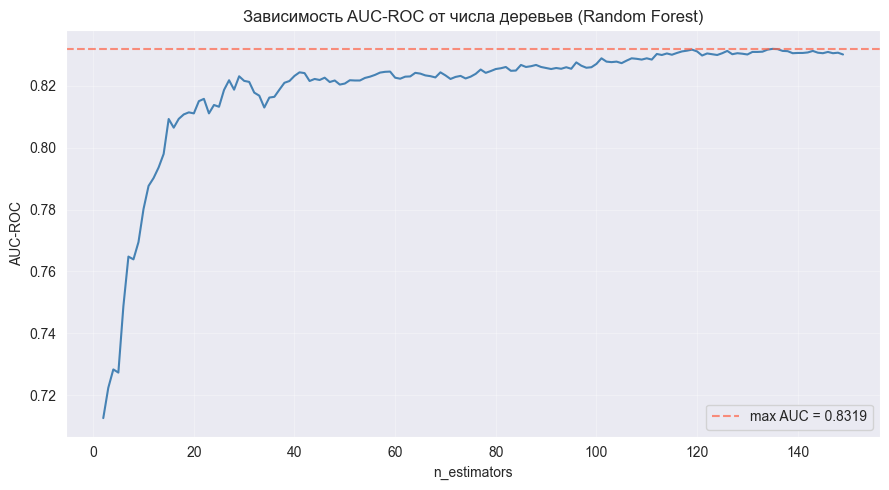

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(n_estimators_values, auc_roc_by_n, color="steelblue")
plt.axhline(y=max(auc_roc_by_n), color="tomato", linestyle="--", alpha=0.7,
            label=f"max AUC = {max(auc_roc_by_n):.4f}")
plt.xlabel("n_estimators")
plt.ylabel("AUC-ROC")
plt.title("Зависимость AUC-ROC от числа деревьев (Random Forest)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод.** С ростом параметра n_estimators растёт значение ROC AUC – это хорошо, ведь чем больше ROC AUC, тем лучше модель разделяет классы.
При этом эффективность в повышении значения этой метрики сильно снижается после 40 деревьев, поэтому не имеет смысла обучать модель на слишком большом количестве деревьев (>50-60).
Видимо, это связано с тем, что примерно на 40 деревьях случайный лес выучил основные зависимости. Дальше имеет смысл менять глубину и количество признаков для разбиения. 

### 5.7 Важность признаков

Оценим важность признаков в лучшей модели Random Forest по Mean Decrease in Impurity по всем деревьям.

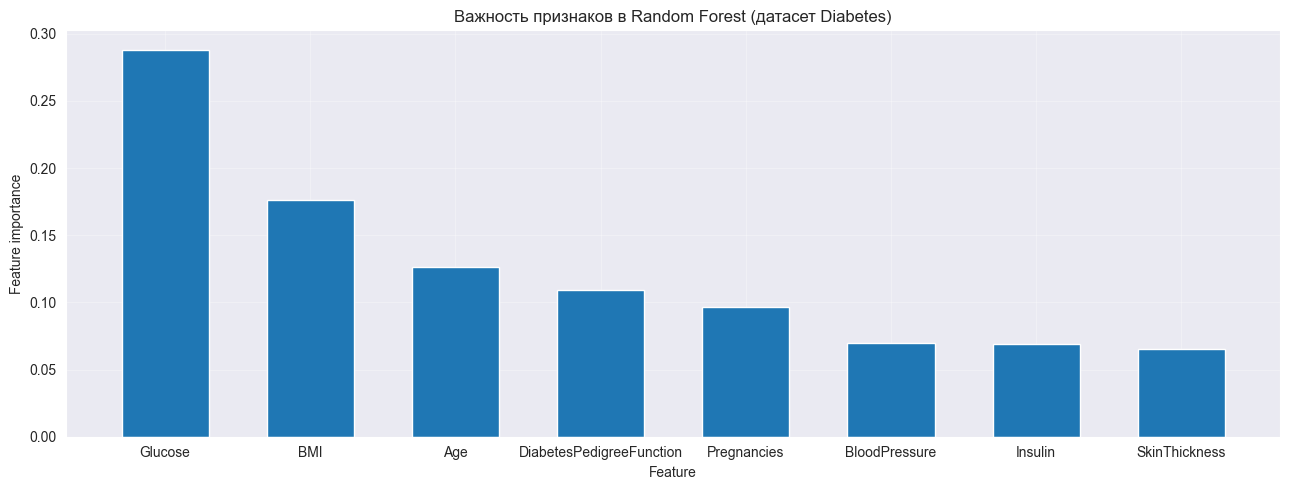

In [20]:
importances: np.ndarray = best_model.feature_importances_
feature_names = x.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(13, 5))
plt.bar(feature_names[sorted_idx], importances[sorted_idx], width=0.6)
plt.ylabel("Feature importance")
plt.xlabel("Feature")
plt.title("Важность признаков в Random Forest (датасет Diabetes)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод.** Самым важным признаком оказалось содержание глюкозы в крови. Следующий по важности признак - это BMI, индекс массы тела.
Это совпадает с реальностью, поскольку содержание сахара в крови и показывает наличие диабета у человека. Диабетики постоянно следят за уровнем сахара.

А люди с повышенным ИМТ с большей вероятностью питаются пищей с высоким содержанием сахара, поэтому они с большей вероятностью больны диабетом или заболеют им.

## 6. Сравнительный анализ моделей

Сведём метрики трёх моделей в единую таблицу и проведём итоговый анализ.

In [21]:
results = {
    "Модель": [
        "DecisionTree (ручная реализация)",
        "DecisionTree (sklearn, подбор гиперпараметров)",
        "BaggingClassifier (50 деревьев)",
        "RandomForestClassifier (50 деревьев, подбор гиперпараметров)",
    ],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "AUC-ROC": [],
}

# 0) Ручная реализация DecisionTree
# Все признаки вещественные; predict_proba не реализована, поэтому AUC-ROC недоступен
_feature_types_d = ["real"] * x_train.shape[1]
_m0 = DecisionTree(feature_types=_feature_types_d, task="classification")
_m0.fit(x_train.values, y_train.values)
_p0 = _m0.predict(x_test.values)
results["Accuracy"].append(round(accuracy_score(y_test, _p0), 4))
results["Precision"].append(round(precision_score(y_test, _p0), 4))
results["Recall"].append(round(recall_score(y_test, _p0), 4))
results["AUC-ROC"].append("N/A")

# 1) Решающее дерево из sklearn
_best_dt_score = 0
_best_dt_params = (3, 2)

for _depth in np.arange(1, 20):
    for _msl in np.arange(1, 15):
        _m = DecisionTreeClassifier(max_depth=_depth, min_samples_leaf=_msl, random_state=42)
        _s = cross_val_score(_m, x_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring='f1').mean()
        if _s > _best_dt_score:
            _best_dt_score = _s
            _best_dt_params = (_depth, _msl)

_m1 = DecisionTreeClassifier(max_depth=_best_dt_params[0],
                             min_samples_leaf=_best_dt_params[1],
                             random_state=42)
_m1.fit(x_train, y_train)
_p1 = _m1.predict(x_test)
_pr1 = _m1.predict_proba(x_test)[:, 1]
results["Accuracy"].append(round(accuracy_score(y_test, _p1), 4))
results["Precision"].append(round(precision_score(y_test, _p1), 4))
results["Recall"].append(round(recall_score(y_test, _p1), 4))
results["AUC-ROC"].append(round(roc_auc_score(y_test, _pr1), 4))

# 2) Bagging
_m2 = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                        n_estimators=50, random_state=42, n_jobs=-1)
_m2.fit(x_train, y_train)
_p2 = _m2.predict(x_test)
_pr2 = _m2.predict_proba(x_test)[:, 1]
results["Accuracy"].append(round(accuracy_score(y_test, _p2), 4))
results["Precision"].append(round(precision_score(y_test, _p2), 4))
results["Recall"].append(round(recall_score(y_test, _p2), 4))
results["AUC-ROC"].append(round(roc_auc_score(y_test, _pr2), 4))

# 3) Random Forest (best_model уже обучен выше)
_p3 = best_model.predict(x_test)
_pr3 = best_model.predict_proba(x_test)[:, 1]
results["Accuracy"].append(round(accuracy_score(y_test, _p3), 4))
results["Precision"].append(round(precision_score(y_test, _p3), 4))
results["Recall"].append(round(recall_score(y_test, _p3), 4))
results["AUC-ROC"].append(round(roc_auc_score(y_test, _pr3), 4))

df_results = pd.DataFrame(results).set_index("Модель")
df_results

,Accuracy,Precision,Recall,AUC-ROC
Модель,,,,
DecisionTree (ручная реализация),0.7662,0.7077,0.5679,N/A
"DecisionTree (sklearn, подбор гиперпараметров)",0.6926,0.5676,0.5185,0.6526
BaggingClassifier (50 деревьев),0.7532,0.6875,0.5432,0.8269
"RandomForestClassifier (50 деревьев, подбор гиперпараметров)",0.7446,0.6667,0.5432,0.8207


### Выводы


Получили, что ручная реализация показывает наилучшие значения по первым трём метрикам, но, очевидно, это связано с тем, что оно переобучено: без регулировки максимальной глубины оно растёт до упора и "лучше" запоминает обучающую выборку.

Одиночное дерево sklearn показало худший результат по всем метрикам, включая AUC = 0.65. Это говорит о том, что даже с подбором гиперпараметров одно дерево нестабильно на этом датасете.

Бэггинг и случайный лес показали практически одинаковый AUC (~0.82–0.83) – это главная метрика здесь, потому что классы несбалансированы (65:35).

Recall у всех моделей низкий (0.51-0.57) – это значит, что примерно половина больных диабетом не распознаётся. В медицинском контексте это важно: высокий recall критичнее высокого precision, потому что пропустить больного опаснее, чем ложно его заподозрить. Для улучшения recall можно было бы искать подходящие порог классификации или веса классов.